# Traffic Sign Detection for Self-Driving Cars — YOLO vs DETR

A single, run-top-to-bottom pipeline comparing **YOLO** (one-stage CNN) and **DETR**
(transformer) for traffic-sign object detection.

**Dataset:** [pkdarabi/cardetection](https://www.kaggle.com/datasets/pkdarabi/cardetection/data)
— *Traffic Signs Detection* (15 classes). Despite the URL name, the task is traffic-**sign**
detection, not car detection.

**How to use this notebook:** open it in Google Colab (GPU runtime recommended for training),
then run the cells in order. Section 0 sets everything up; later sections inspect the data,
run EDA, and train/evaluate the two baselines.

| Section | What it does | Status |
|---|---|---|
| 0 | Environment setup + dataset download | ✅ |
| 1 | Dataset inspection + annotated samples | ✅ |
| 2 | Exploratory Data Analysis | ✅ |
| 3 | Data quality assessment | ✅ |
| 4 | YOLO baseline (train + evaluate) | ✅ |
| 5 | DETR baseline (train + evaluate) | ✅ |
| 6 | YOLO vs DETR comparison | ✅ |


## 0 · Setup

Mount Drive, clone the repo, install dependencies, and download the dataset.
**Run this once per Colab session before anything else.**

### 0.1 Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 0.2 Clone the repo + make `src` importable

In [2]:
import os, sys, subprocess

GITHUB_REPO = 'https://github.com/huynhphtloi/traffic-sign-detection-yolo-detr'
DRIVE_ROOT  = '/content/drive/MyDrive/MasterProjects/DeepLearning/traffic-sign-detection-yolo-detr'
REPO        = '/content/traffic-sign-detection-yolo-detr'
# Dataset lives on Colab LOCAL disk for speed (Drive is very slow for ~10k small files).
DATA_DIR    = '/content/dataset'

if not os.path.exists(REPO):
    result = subprocess.run(['git', 'clone', GITHUB_REPO, REPO])
    if result.returncode != 0:
        raise RuntimeError('git clone failed - check the repo URL or network access')
else:
    subprocess.run(['git', '-C', REPO, 'pull'], check=True)

if not os.path.exists(f'{REPO}/src'):
    raise RuntimeError(f'Clone succeeded but src/ not found in {REPO}')

os.environ['TSD_DRIVE_ROOT'] = DRIVE_ROOT
os.environ['TSD_REPO_ROOT']  = REPO
os.environ['TSD_DATA_DIR']   = DATA_DIR
if REPO not in sys.path:
    sys.path.insert(0, REPO)

print('drive root:', DRIVE_ROOT)
print('repo root :', REPO)
print('data dir  :', DATA_DIR, '(local disk - fast)')
print('src found :', os.path.exists(f'{REPO}/src'))


drive root: /content/drive/MyDrive/MasterProjects/DeepLearning/traffic-sign-detection-yolo-detr
repo root : /content/traffic-sign-detection-yolo-detr
data dir  : /content/dataset (local disk - fast)
src found : True


### 0.3 Install dependencies

In [3]:
import os
REPO = os.environ['TSD_REPO_ROOT']
!pip install -q -r {REPO}/requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 17.9 MB/s eta 0:00:00


### 0.4 Dataset source

Choose **one** source for the dataset and set `DATASET_SOURCE` in the cell below.

| Value | When to use |
|---|---|
| `'kaggle'` | First run — downloads fresh from Kaggle (requires `kaggle.json` on Drive) |
| `'drive'` | Dataset already saved on Drive — fastest, no re-download |

In [4]:
import os

DRIVE_ROOT = os.environ['TSD_DRIVE_ROOT']
DATA_DIR   = os.environ['TSD_DATA_DIR']

# ── Pick your source ────────────────────────────────────────────────────────
DATASET_SOURCE = 'kaggle'   # 'kaggle'  or  'drive'

# Used only when DATASET_SOURCE == 'drive':
# Absolute Drive path to the folder that already contains data.yaml + train/valid/test/
DRIVE_DATASET_PATH = f'{DRIVE_ROOT}/dataset/raw'

# ────────────────────────────────────────────────────────────────────────────
if DATASET_SOURCE == 'kaggle':
    print(f'Source : kaggle  (pkdarabi/cardetection → {DATA_DIR}/raw)')
elif DATASET_SOURCE == 'drive':
    print(f'Source : drive   ({DRIVE_DATASET_PATH})')
else:
    raise ValueError(f'DATASET_SOURCE must be "kaggle" or "drive", got {DATASET_SOURCE!r}')

Source : kaggle  (pkdarabi/cardetection → /content/dataset/raw)


### 0.5 Download / locate dataset

- **Kaggle**: installs credentials from Drive, then downloads and unzips the dataset (~300 MB).  
  Requires `kaggle.json` stored at your Drive project root (same folder as `DRIVE_ROOT`).
- **Drive**: symlinks your pre-downloaded dataset folder into the local workspace — no download needed.  
  Make sure `DRIVE_DATASET_PATH` in cell 0.4 points to the folder containing `data.yaml`.

In [5]:
import os, pathlib, zipfile, time
from google.colab import files

DATA_DIR   = os.environ['TSD_DATA_DIR']
DRIVE_ROOT = os.environ['TSD_DRIVE_ROOT']
raw = pathlib.Path(DATA_DIR) / 'raw'
raw.mkdir(parents=True, exist_ok=True)

if DATASET_SOURCE == 'kaggle':
    print('A file picker will appear - select your kaggle.json')
    uploaded = files.upload()
    if 'kaggle.json' not in uploaded:
        raise ValueError('You must upload a file named kaggle.json')
    os.makedirs('/root/.kaggle', exist_ok=True)
    with open('/root/.kaggle/kaggle.json', 'wb') as f:
        f.write(uploaded['kaggle.json'])
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
    print('kaggle.json installed')

    # 1) Download the zip (kaggle shows a % bar) WITHOUT --unzip
    print('\n[1/2] Downloading dataset zip...')
    !kaggle datasets download -d pkdarabi/cardetection -p {DATA_DIR}/raw

    # 2) Unzip OURSELVES with a live progress counter (the slow step - now observable)
    zips = list(raw.glob('*.zip'))
    if not zips:
        raise FileNotFoundError('No .zip found after download')
    zpath = zips[0]
    print(f'\n[2/2] Extracting {zpath.name} -> {raw} (local disk)')
    with zipfile.ZipFile(zpath) as zf:
        members = zf.namelist()
        total = len(members)
        t0 = time.time()
        for i, m in enumerate(members, 1):
            zf.extract(m, raw)
            if i % 500 == 0 or i == total:
                pct = 100 * i / total
                rate = i / max(time.time() - t0, 1e-6)
                eta = (total - i) / rate if rate else 0
                print(f'  {pct:5.1f}%  ({i}/{total} files)  ~{eta:4.0f}s left', flush=True)
    print(f'Extracted {total} files in {time.time()-t0:.0f}s')

elif DATASET_SOURCE == 'drive':
    src = pathlib.Path(DRIVE_DATASET_PATH)
    if not src.exists():
        raise FileNotFoundError(
            f'Drive dataset not found: {DRIVE_DATASET_PATH}\n'
            'Update DRIVE_DATASET_PATH in cell 0.4 to the folder containing data.yaml.'
        )
    link = raw / src.name
    if not link.exists():
        link.symlink_to(src.resolve())
        print(f'Linked  {link} -> {src.resolve()}')
    else:
        print(f'Already linked: {link}')

print()
!ls {DATA_DIR}/raw


A file picker will appear - select your kaggle.json


Saving kaggle.json to kaggle.json
kaggle.json installed

[1/2] Downloading dataset zip...
Dataset URL: https://www.kaggle.com/datasets/pkdarabi/cardetection
License(s): Attribution 4.0 International (CC BY 4.0)
100% 99.8M/99.8M [00:00<00:00, 246MB/s]


[2/2] Extracting cardetection.zip -> /content/dataset/raw (local disk)
    5.0%  (500/9942 files)  ~   2s left
   10.1%  (1000/9942 files)  ~   1s left
   15.1%  (1500/9942 files)  ~   1s left
   20.1%  (2000/9942 files)  ~   1s left
   25.1%  (2500/9942 files)  ~   1s left
   30.2%  (3000/9942 files)  ~   1s left
   35.2%  (3500/9942 files)  ~   1s left
   40.2%  (4000/9942 files)  ~   1s left
   45.3%  (4500/9942 files)  ~   1s left
   50.3%  (5000/9942 files)  ~   1s left
   55.3%  (5500/9942 files)  ~   1s left
   60.4%  (6000/9942 files)  ~   1s left
   65.4%  (6500/9942 files)  ~   1s left
   70.4%  (7000/9942 files)  ~   0s left
   75.4%  (7500/9942 files)  ~   0s left
   80.5%  (8000/9942 files)  ~   0s left
   85.5%  (8500/9942 

### 0.6 Organise into `data/processed/cardetection/`

The Roboflow export unzips to a single subfolder. This finds it and symlinks it to
`data/processed/cardetection` so every script resolves to the same root.

In [6]:
import os, pathlib

DATA_DIR = pathlib.Path(os.environ['TSD_DATA_DIR'])
raw = DATA_DIR / 'raw'
processed = DATA_DIR / 'processed' / 'cardetection'

# Find the subfolder that contains data.yaml (the Roboflow export root).
export_root = None
for candidate in [raw, *raw.iterdir()]:
    if (candidate / 'data.yaml').exists():
        export_root = candidate
        break

if export_root is None:
    raise FileNotFoundError('Could not locate data.yaml under data/raw — check the download.')

processed.parent.mkdir(parents=True, exist_ok=True)
if not processed.exists():
    processed.symlink_to(export_root.resolve())
    print(f'symlinked {processed} -> {export_root}')
else:
    print(f'already exists: {processed}')

for split in ('train', 'valid', 'test'):
    imgs = list((processed / split / 'images').glob('*')) if (processed / split / 'images').exists() else []
    print(f'  {split}: {len(imgs)} images')

symlinked /content/dataset/processed/cardetection -> /content/dataset/raw/car
  train: 3530 images
  valid: 801 images
  test: 638 images


## 1 · Dataset Inspection

Detect the dataset layout/format, counts, classes, and splits — **without assuming** — then
render annotated samples. Writes `results/tables/dataset_summary.csv` and syncs `configs/*.yaml`.

### 1.1 Inspect structure + sync configs

In [7]:
from src.data.inspect_dataset import inspect, write_configs
from src.utils.paths import DATA_PROCESSED
df = inspect(DATA_PROCESSED)
write_configs(DATA_PROCESSED)   # regenerate configs/classes.yaml + data.yaml from data.yaml
df

[inspect] train: 3530 images — counting labels...
[inspect]   train: 500/3530 done
[inspect]   train: 1000/3530 done
[inspect]   train: 1500/3530 done
[inspect]   train: 2000/3530 done
[inspect]   train: 2500/3530 done
[inspect]   train: 3000/3530 done
[inspect]   train: 3500/3530 done
[inspect] train: 3530 label files, 4298 boxes
[inspect] valid: 801 images — counting labels...
[inspect]   valid: 500/801 done
[inspect] valid: 801 label files, 944 boxes
[inspect] test: 638 images — counting labels...
[inspect]   test: 500/638 done
[inspect] test: 638 label files, 770 boxes
[write-configs] synced /content/traffic-sign-detection-yolo-detr/configs/classes.yaml and /content/traffic-sign-detection-yolo-detr/configs/data.yaml (15 classes)


,split,exists,images,label_files,boxes,format,num_classes
0,train,True,3530,3530,4298,YOLO TXT (Roboflow/Ultralytics),15
1,valid,True,801,801,944,YOLO TXT (Roboflow/Ultralytics),15
2,test,True,638,638,770,YOLO TXT (Roboflow/Ultralytics),15


### 1.2 Annotated samples (required before training)

[visualize] 1/12 — 000235_jpg.rf.58009e601f129b35cbbb2dbb6336cfc2.jpg
[visualize] 2/12 — FisheyeCamera_1_00497_png.rf.241cc03642cdc931bcb50b1c4947595f.jpg
[visualize] 3/12 — FisheyeCamera_1_00037_png.rf.d53f485532f8b13198f33f1d91c4a49f.jpg
[visualize] 4/12 — 001466_jpg.rf.5f1e09ac149f516e67ac48f70c3b761d.jpg
[visualize] 5/12 — 00005_00027_00014_png.rf.354f184dc18038e7d5e51edca842a27e.jpg
[visualize] 6/12 — FisheyeCamera_1_00223_png.rf.b4ceca7a7093f72a7c0c50e12408dcb1.jpg
[visualize] 7/12 — road545_png.rf.02614a36cb366d36c8c23deca405fc02.jpg
[visualize] 8/12 — 00008_00034_00007_png.rf.08a62227cc74501de6baeb62505431db.jpg
[visualize] 9/12 — FisheyeCamera_1_00641_png.rf.70f3b246fc151f31ad2d0eda859a929b.jpg
[visualize] 10/12 — 000430_jpg.rf.1008366e8e2805837605a83fc64bc470.jpg
[visualize] 11/12 — 00004_00038_00010_png.rf.ccb068d57bc46d80e2e13f92a9dffca7.jpg
[visualize] 12/12 — 000796_jpg.rf.f53632340c6f9441e54f4da49904cf97.jpg
[visualize] done — wrote 12 annotated images to /content/traffi

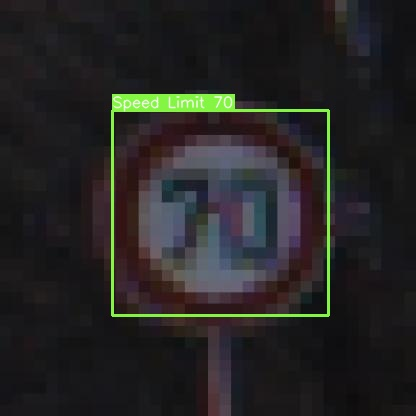

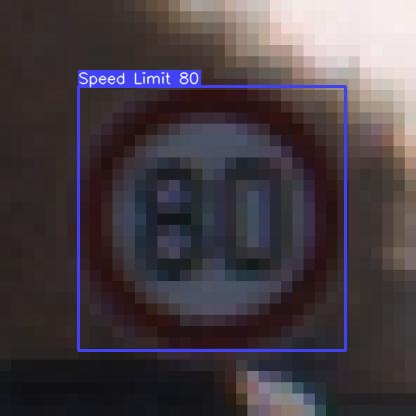

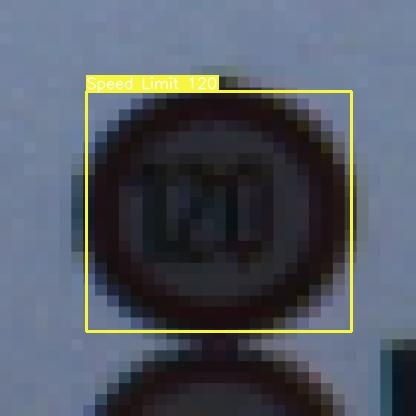

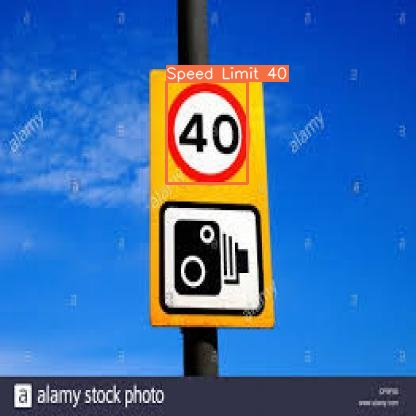

In [8]:
from src.data.visualize_annotations import visualize
out = visualize('train', n=12)
from IPython.display import Image, display
import os
for f in sorted(os.listdir(out))[:4]:
    display(Image(filename=str(out / f)))

## 2 · Exploratory Data Analysis

Class distribution + imbalance, bounding-box statistics, image statistics, and the
object-center heatmap. Saves plots to `results/eda/` and tables to `results/tables/`.



[class_distribution] Most frequent: Red Light (787)
[class_distribution] Least frequent: Speed Limit 10 (22)
[class_distribution] Imbalance ratio: 35.77x
[class_distribution] Generated plot in /content/traffic-sign-detection-yolo-detr/results/eda
[class_distribution] Saved table to /content/traffic-sign-detection-yolo-detr/results/tables/class_distribution.csv
[bbox_statistics] Generated plots in /content/traffic-sign-detection-yolo-detr/results/eda
[bbox_statistics] Saved size categories to /content/traffic-sign-detection-yolo-detr/results/tables/bbox_size_categories.csv
[image_statistics] Total images: 4969
[image_statistics] Average objects per image: 1.21
[image_statistics] Generated plots in /content/traffic-sign-detection-yolo-detr/results/eda
[image_statistics] Saved table to /content/traffic-sign-detection-yolo-detr/results/tables/image_statistics.csv
[heatmap_analysis] Generated heatmap in /content/traffic-sign-detection-yolo-detr/results/eda

--- bbox_area.png ---


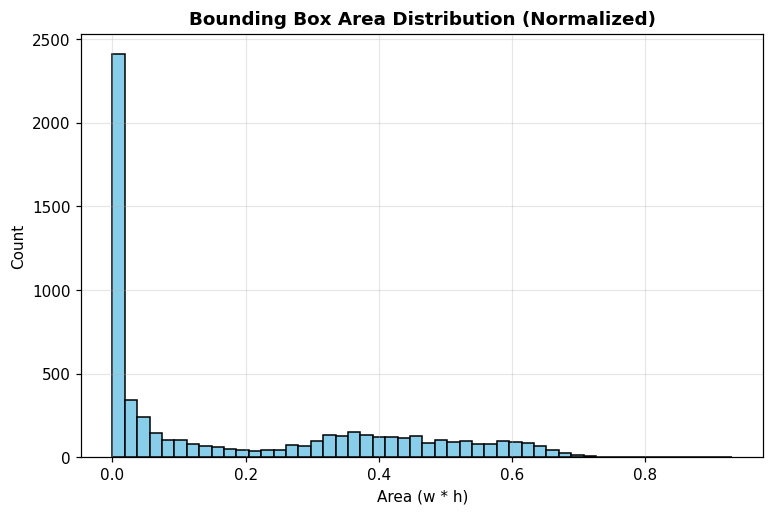


--- bbox_aspect_ratio.png ---


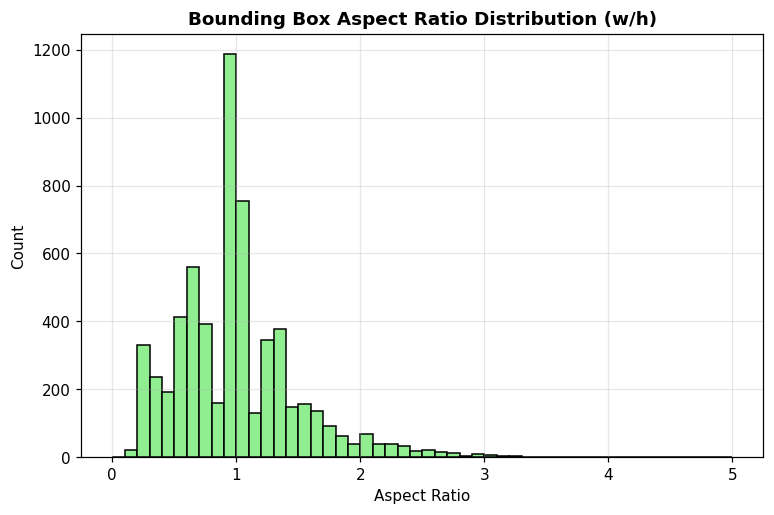


--- bbox_size_categories.png ---


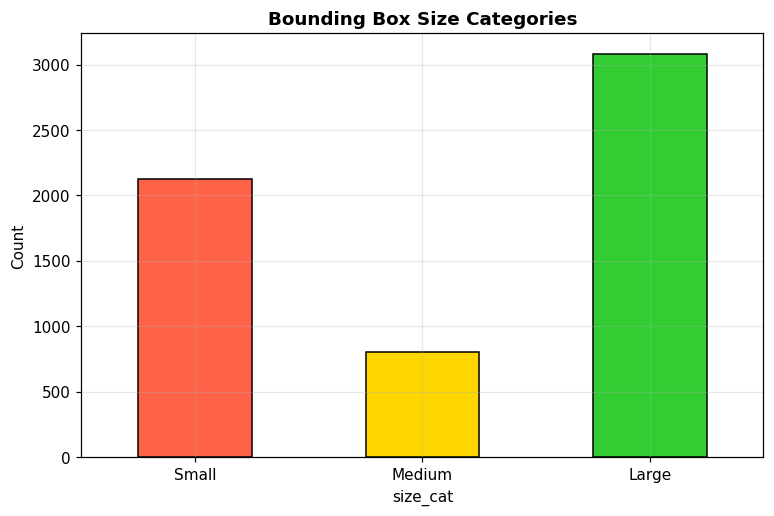


--- bbox_wh.png ---


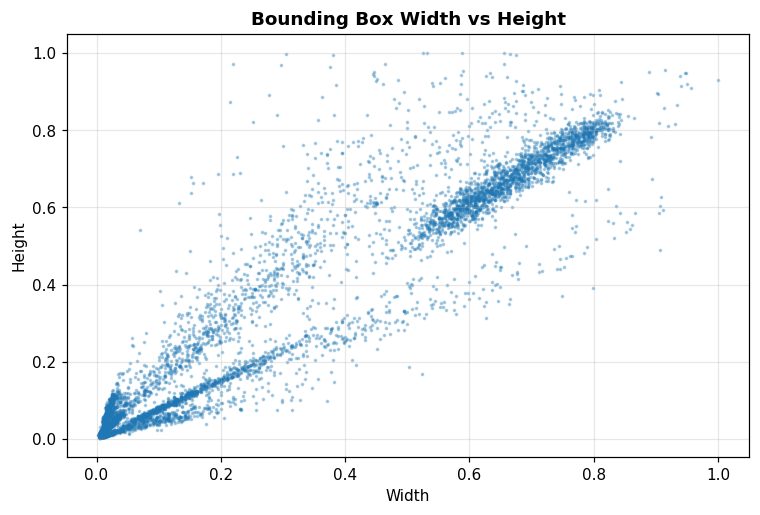


--- class_distribution.png ---


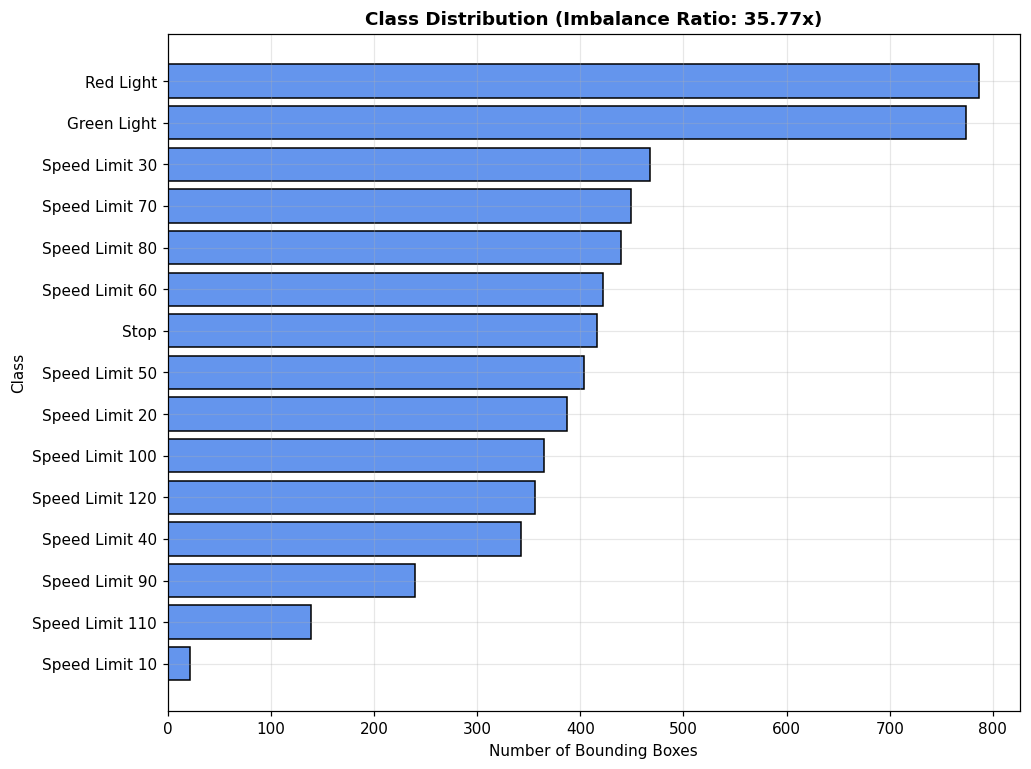


--- image_resolution.png ---


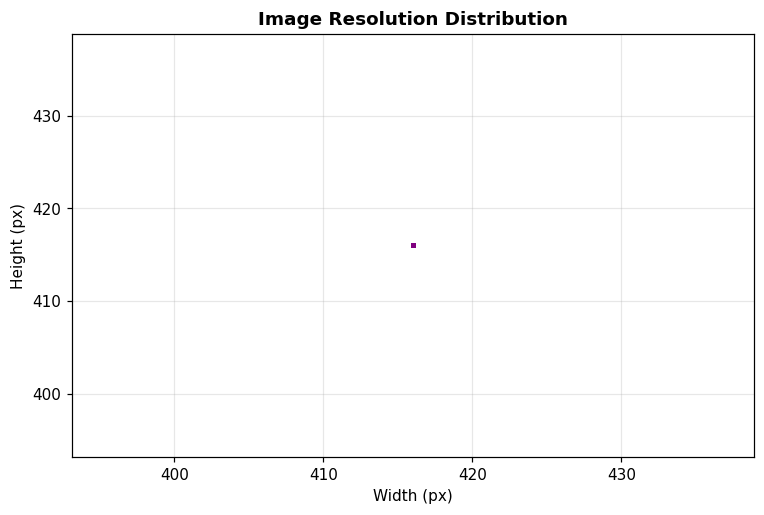


--- images_per_split.png ---


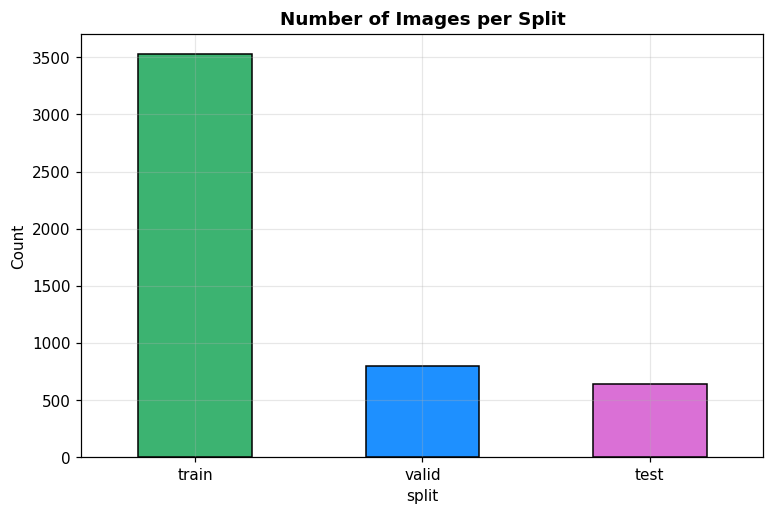


--- object_center_heatmap.png ---


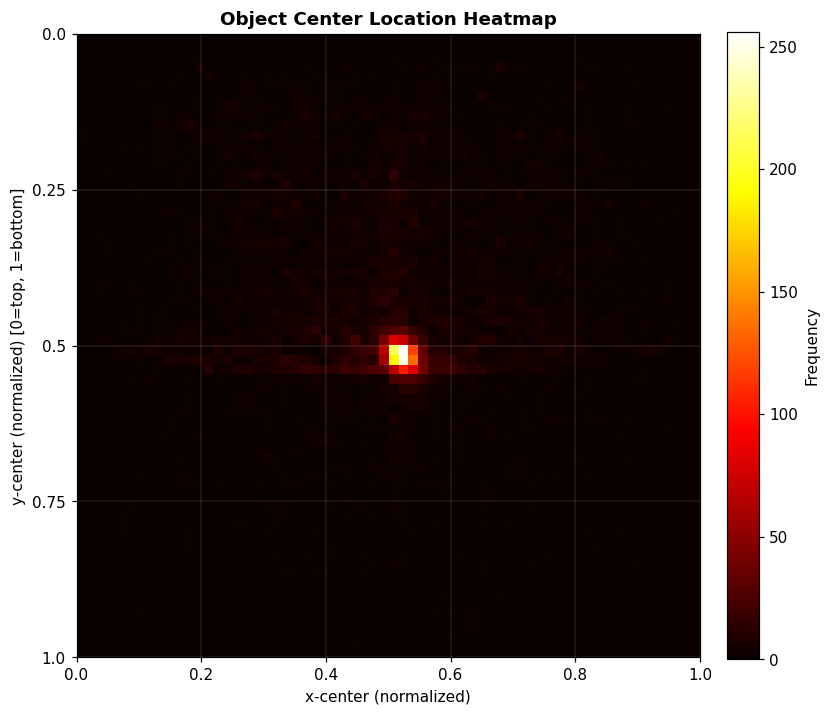


--- objects_per_image.png ---


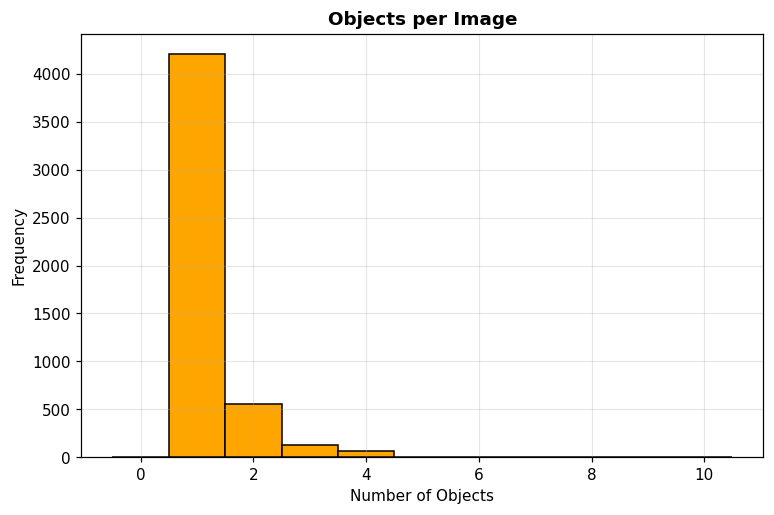

In [9]:
from src.eda.class_distribution import run as class_dist; class_dist()
from src.eda.bbox_statistics import run as bbox_stats; bbox_stats()
from src.eda.image_statistics import run as image_stats; image_stats()
from src.eda.heatmap_analysis import run as heatmap; heatmap()

from IPython.display import Image, display
import glob
from src.utils.paths import RESULTS_EDA

# Display all generated EDA plots
for img_path in sorted(RESULTS_EDA.glob('*.png')):
    print(f'\n--- {img_path.name} ---')
    display(Image(filename=str(img_path)))


## 3 · Data Quality Assessment

Quality report (missing/empty/invalid/corrupt/duplicate) plus a difficult-sample gallery
(small / blurry / low-light signs).



In [10]:
from src.data.validate_labels import validate, summarize
from src.utils.paths import DATA_PROCESSED

rep = validate(DATA_PROCESSED)
print(summarize(rep))
rep.head()


Total issues: 4
  empty_label: 4


,split,image,issue_type,detail
0,train,FisheyeCamera_1_00802_png.rf.6a502d781364b74f3...,empty_label,Label file exists but contains no valid boxes
1,train,FisheyeCamera_1_00807_png.rf.065f778b2eaf15dd7...,empty_label,Label file exists but contains no valid boxes
2,train,FisheyeCamera_1_00926_png.rf.511cfac04ff48a1fe...,empty_label,Label file exists but contains no valid boxes
3,test,FisheyeCamera_1_00922_png.rf.408835a278b9c700e...,empty_label,Label file exists but contains no valid boxes


## 4 · YOLO Baseline

Train YOLOv8n (pretrained, imgsz 640, flip-LR OFF) and evaluate on the test split.
**Needs a GPU.** Writes `weights/yolo/yolo_baseline/best.pt` and
`results/metrics/yolo_baseline.json`.

### 4.1 Train

In [11]:
import time
from src.training.train_yolo import train

print('⏳ YOLO training started — this is the longest step (~1.5–2.5 h on Colab T4 for 30 epochs).')
print('   Watch the per-epoch table below; live metrics also stream to runs/detect/yolo_baseline/results.csv')
_t0 = time.time()
results, best = train(model='yolov8n.pt', epochs=30, name='yolo_baseline')
print(f'✅ YOLO training done in {(time.time()-_t0)/60:.1f} min')
print('best checkpoint:', best)


⏳ YOLO training started — this is the longest step (~1.5–2.5 h on Colab T4 for 30 epochs).
   Watch the per-epoch table below; live metrics also stream to runs/detect/yolo_baseline/results.csv
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
[train_yolo] ▶ starting: model=yolov8n.pt epochs=30 imgsz=640 batch=16 device=auto
[train_yolo]   data config: /content/traffic-sign-detection-yolo-detr/configs/data.local.yaml
[train_yolo]   this is the long step — watch per-epoch mAP in the table below / runs/detect/<name>/results.csv
Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5,

### 4.2 Evaluate on the test split (mAP, P, R, FPS, size) → metrics JSON

In [12]:
import time, json
from src.evaluation.evaluate_yolo import evaluate
from src.utils.paths import RESULTS_METRICS, ensure_dir

print('⏳ Evaluating YOLO on the test split + benchmarking FPS...')
_t0 = time.time()
metrics = evaluate(best, split='test')
ensure_dir(RESULTS_METRICS)
(RESULTS_METRICS / 'yolo_baseline.json').write_text(json.dumps(metrics, indent=2))
print(f'✅ YOLO eval done in {(time.time()-_t0):.0f}s → results/metrics/yolo_baseline.json')
metrics


⏳ Evaluating YOLO on the test split + benchmarking FPS...
[evaluate_yolo] ▶ validating /content/traffic-sign-detection-yolo-detr/weights/yolo/yolo_baseline/best.pt on split='test' (device=auto)
Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,008,573 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 478.1±85.1 MB/s, size: 21.9 KB)
val: Scanning /content/dataset/raw/car/test/labels... 638 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 638/638 1.2Kit/s 0.5s
val: New cache created: /content/dataset/raw/car/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 40/40 7.0it/s 5.7s
                   all        638        770      0.908      0.956      0.954      0.806
           Green Light         77        110      0.853      0.895      0.909      0.547
             Red Light         71         94      0.839  

{'model': 'YOLO',
 'weights': '/content/traffic-sign-detection-yolo-detr/weights/yolo/yolo_baseline/best.pt',
 'split': 'test',
 'map50': 0.9538574376926128,
 'map50_95': 0.8058027647147404,
 'precision': 0.9083972124008189,
 'recall': 0.9563594876339004,
 'model_size_mb': 6.25,
 'device': 'auto',
 'latency_ms': 8.83,
 'fps': 113.2}

### 4.3 Training curves

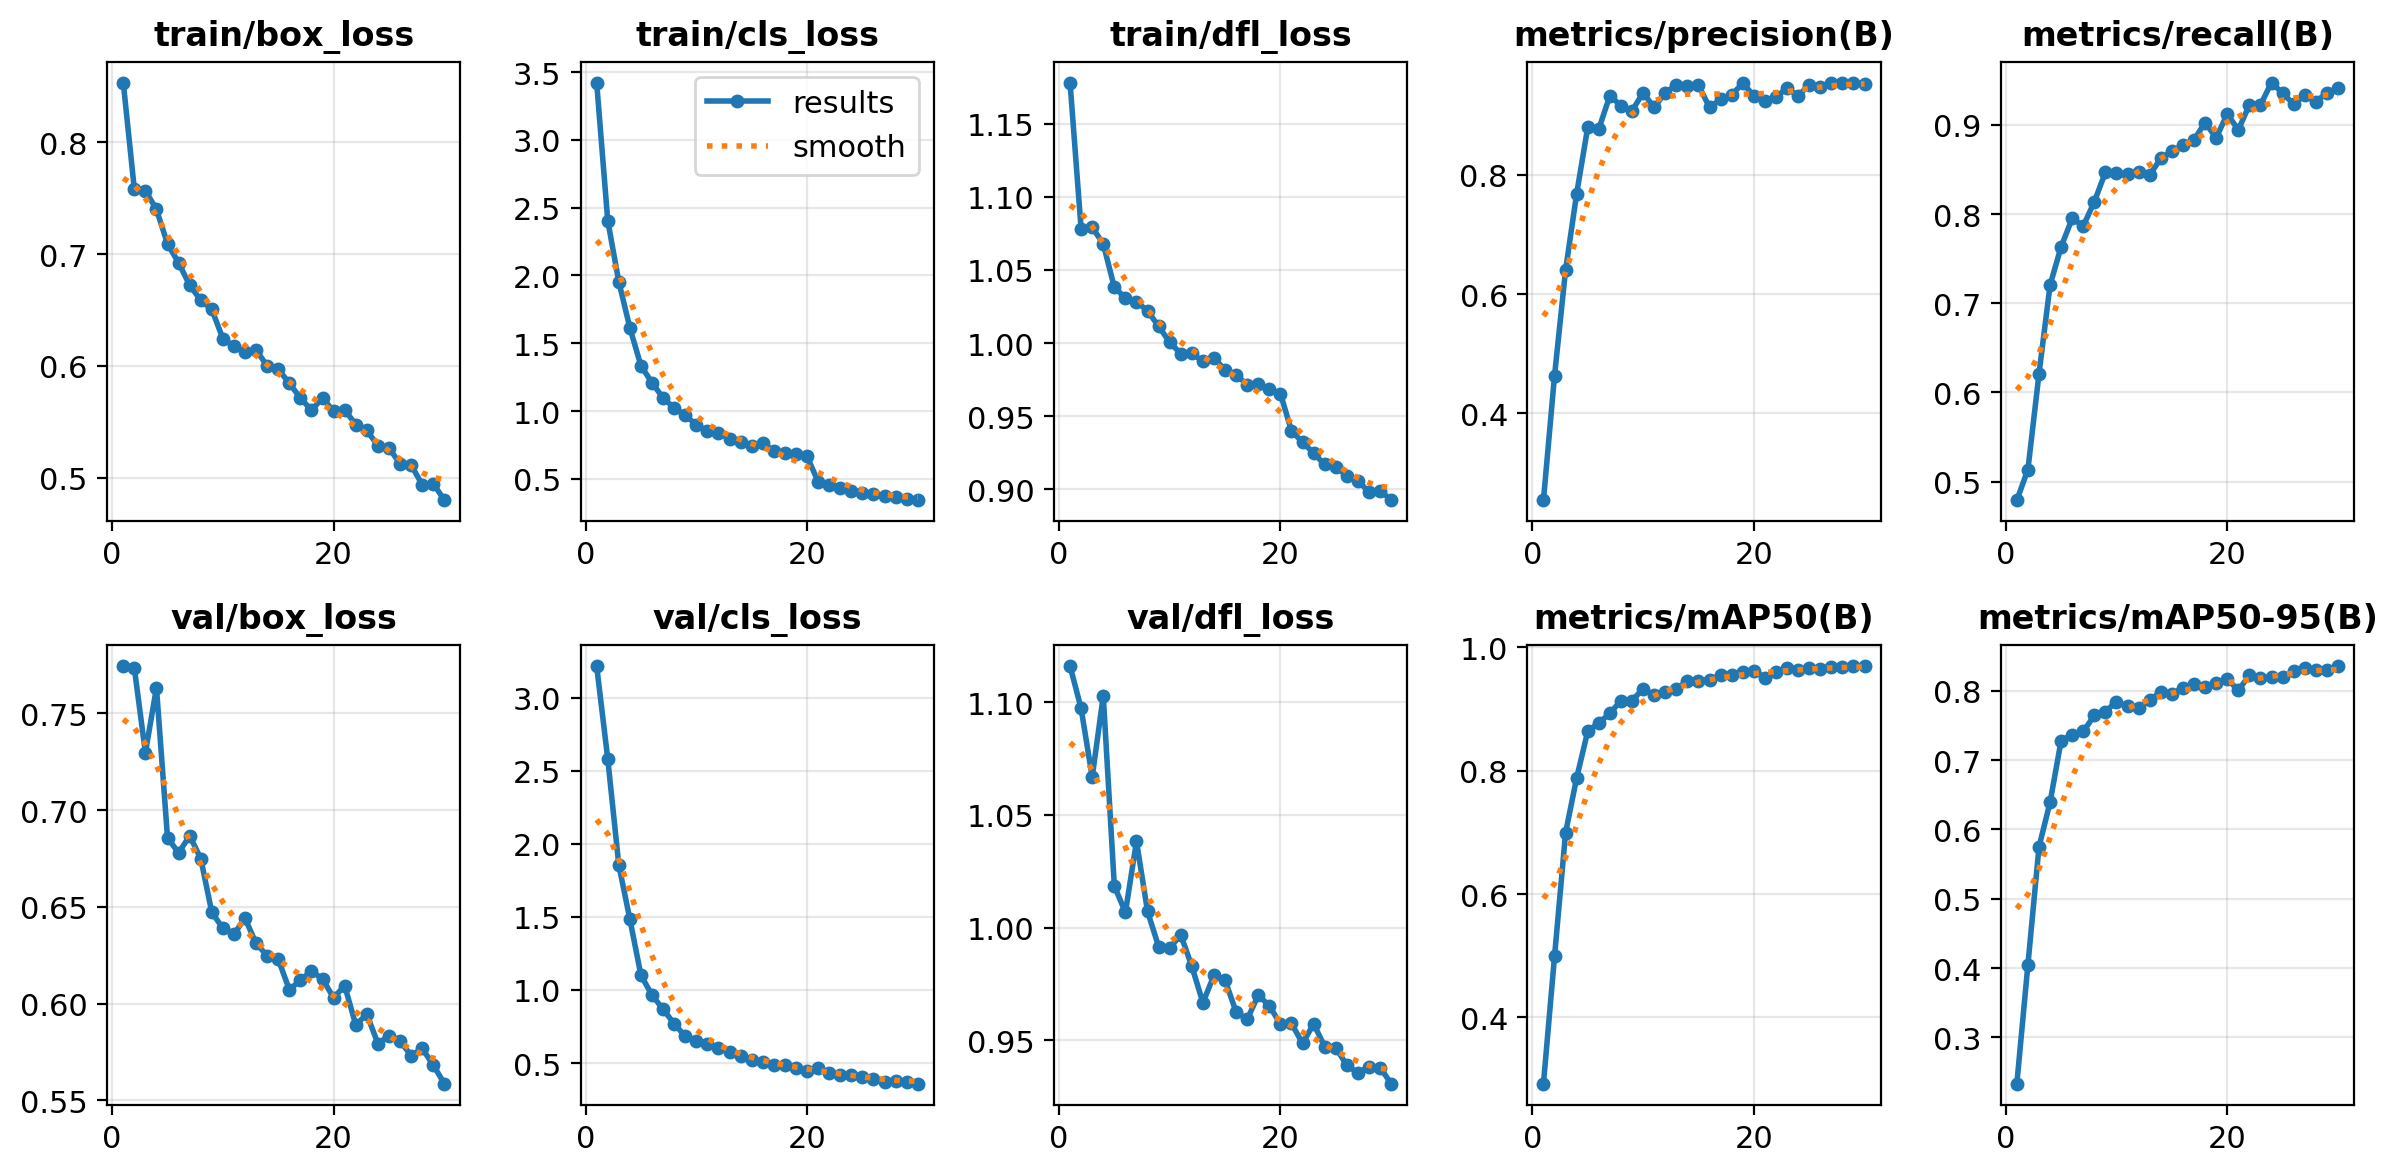

In [13]:
from IPython.display import Image
from src.utils.paths import WEIGHTS_YOLO
Image(filename=str(WEIGHTS_YOLO / 'yolo_baseline' / 'training_curves.png'))

## 5 · DETR Baseline

Convert to COCO, fine-tune `facebook/detr-resnet-50` (lightweight: batch 2, ~10 epochs),
and evaluate. **Needs a GPU.**

In [15]:
# ═══ §5 · DETR Baseline (self-contained, stability-fixed) ═══
import time, json, torch
from pathlib import Path
from torch.utils.data import DataLoader
from transformers import DetrForObjectDetection, DetrImageProcessor

# reuse the repo's dataset + collate (these are fine; the bug was only in the train loop)
from src.training.train_detr import CocoDetrDataset, collate_fn
from src.data.convert_to_coco import convert
from src.evaluation.evaluate_detr import evaluate
from src.utils.paths import DATA_COCO, WEIGHTS_DETR, RESULTS_METRICS, ensure_dir
from src.utils.seeding import seed_everything


def train_detr_fixed(epochs=10, batch=2, lr=1e-5, lr_backbone=1e-6,
                     name="detr_baseline", coco_dir=DATA_COCO, out_root=WEIGHTS_DETR):
    device = "cuda" if torch.cuda.is_available() else (
        "mps" if torch.backends.mps.is_available() else "cpu")
    print(f"[detr] device={device} epochs={epochs} batch={batch} "
          f"lr(head)={lr} lr(backbone)={lr_backbone}")
    seed_everything()

    processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
    model = DetrForObjectDetection.from_pretrained(
        "facebook/detr-resnet-50", num_labels=15, ignore_mismatched_sizes=True).to(device)

    train_ds = CocoDetrDataset(coco_dir / "instances_train.json", processor)
    val_ds   = CocoDetrDataset(coco_dir / "instances_valid.json", processor)
    train_loader = DataLoader(train_ds, batch_size=batch, shuffle=True,
                              collate_fn=collate_fn, num_workers=2)
    val_loader   = DataLoader(val_ds, batch_size=batch, shuffle=False,
                              collate_fn=collate_fn, num_workers=2)

    # ── KEY FIX: separate, low LRs for backbone vs head (uniform 1e-4 → NaN) ──
    backbone_params, head_params = [], []
    for pname, p in model.named_parameters():
        if not p.requires_grad:
            continue
        (backbone_params if "backbone" in pname else head_params).append(p)
    optimizer = torch.optim.AdamW(
        [{"params": head_params, "lr": lr},
         {"params": backbone_params, "lr": lr_backbone}], weight_decay=1e-4)

    n_train, n_val = len(train_loader), len(val_loader)
    print(f"[detr] ▶ {n_train} train / {n_val} val batches per epoch")

    best_val, best_epoch = float("inf"), 0
    for epoch in range(1, epochs + 1):
        t0 = time.perf_counter()
        model.train(); total = 0.0
        for step, b in enumerate(train_loader):
            pv = b["pixel_values"].to(device); pm = b["pixel_mask"].to(device)
            labels = [{k: v.to(device) for k, v in l.items()} for l in b["labels"]]
            loss = model(pixel_values=pv, pixel_mask=pm, labels=labels).loss

            if not torch.isfinite(loss):              # ── NaN guard ──
                print(f"[detr]   ⚠ non-finite loss e{epoch} s{step}; skipping")
                optimizer.zero_grad(); continue

            optimizer.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
            optimizer.step(); total += loss.item()
            if step % 50 == 0:
                el = time.perf_counter() - t0
                rate = (step + 1) / el if el > 0 else 0
                eta = (n_train - step - 1) / rate / 60 if rate else 0
                print(f"[detr] e{epoch}/{epochs} | b{step}/{n_train} "
                      f"| loss {loss.item():.4f} | {rate:.1f} it/s | ~{eta:.1f} min left")

        avg_train = total / n_train

        # validate (NaN-safe)
        model.eval(); vsum, vok = 0.0, 0
        with torch.no_grad():
            for b in val_loader:
                pv = b["pixel_values"].to(device); pm = b["pixel_mask"].to(device)
                labels = [{k: v.to(device) for k, v in l.items()} for l in b["labels"]]
                vl = model(pixel_values=pv, pixel_mask=pm, labels=labels).loss
                if torch.isfinite(vl):
                    vsum += vl.item(); vok += 1
        avg_val = vsum / vok if vok else float("inf")
        print(f"[detr] ✔ epoch {epoch}/{epochs}  train={avg_train:.4f}  "
              f"val={avg_val:.4f}  ({(time.perf_counter()-t0)/60:.1f} min)")

        if avg_val < best_val:                         # save BEST only
            best_val, best_epoch = avg_val, epoch
            out = ensure_dir(out_root / name)
            model.save_pretrained(out); processor.save_pretrained(out)
            print(f"[detr]   ↳ new best (val={avg_val:.4f}) → {out}")

    out = ensure_dir(out_root / name)
    if best_epoch == 0:                                # never improved → save final
        model.save_pretrained(out); processor.save_pretrained(out)
    print(f"[detr] done → {out} (best val={best_val:.4f} @ epoch {best_epoch})")
    return out


# ── run: convert → train → evaluate ──
print('⏳ [1/3] Converting YOLO → COCO...')
_t = time.time(); convert(); print(f'   ✅ {(time.time()-_t):.0f}s')

print('⏳ [2/3] Fine-tuning DETR (stability-fixed)...')
_t = time.time()
model_dir = train_detr_fixed(epochs=10, batch=2)
print(f'   ✅ training {(time.time()-_t)/60:.1f} min')

print('⏳ [3/3] Evaluating DETR on test split...')
_t = time.time()
m = evaluate(model_dir, split='test')
ensure_dir(RESULTS_METRICS)
(RESULTS_METRICS / 'detr_baseline.json').write_text(json.dumps(m, indent=2))
print(f'   ✅ eval {(time.time()-_t)/60:.1f} min → results/metrics/detr_baseline.json')
m


⏳ [1/3] Converting YOLO → COCO...
[convert_to_coco] ▶ train: converting 3530 images...
[convert_to_coco]   train: 500/3530 images done
[convert_to_coco]   train: 1000/3530 images done
[convert_to_coco]   train: 1500/3530 images done
[convert_to_coco]   train: 2000/3530 images done
[convert_to_coco]   train: 2500/3530 images done
[convert_to_coco]   train: 3000/3530 images done
[convert_to_coco]   train: 3500/3530 images done
[convert_to_coco] train: 3530 images, 4298 annotations → /content/dataset/coco/instances_train.json
[convert_to_coco] ▶ valid: converting 801 images...
[convert_to_coco]   valid: 500/801 images done
[convert_to_coco] valid: 801 images, 944 annotations → /content/dataset/coco/instances_valid.json
[convert_to_coco] ▶ test: converting 638 images...
[convert_to_coco]   test: 500/638 images done
[convert_to_coco] test: 638 images, 770 annotations → /content/dataset/coco/instances_test.json
   ✅ 1s
⏳ [2/3] Fine-tuning DETR (stability-fixed)...
[detr] device=cuda epochs=1

[transformers] You passed `num_labels=15` which is incompatible to the `id2label` map of length `91`.


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |                                                                                         
---------------------------------------------------------------+------------+-----------------------------------------------------------------------------------------
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |        

[detr] ▶ 1765 train / 401 val batches per epoch
[detr] e1/10 | b0/1765 | loss 3.4833 | 1.1 it/s | ~27.9 min left
[detr] e1/10 | b50/1765 | loss 3.0343 | 1.6 it/s | ~18.3 min left
[detr] e1/10 | b100/1765 | loss 4.4846 | 1.6 it/s | ~17.9 min left
[detr] e1/10 | b150/1765 | loss 2.1748 | 1.6 it/s | ~17.3 min left
[detr] e1/10 | b200/1765 | loss 2.0474 | 1.6 it/s | ~16.7 min left
[detr] e1/10 | b250/1765 | loss 3.2038 | 1.6 it/s | ~16.2 min left
[detr] e1/10 | b300/1765 | loss 2.0828 | 1.6 it/s | ~15.6 min left
[detr] e1/10 | b350/1765 | loss 1.8474 | 1.6 it/s | ~15.1 min left
[detr] e1/10 | b400/1765 | loss 1.0587 | 1.6 it/s | ~14.5 min left
[detr] e1/10 | b450/1765 | loss 1.1922 | 1.6 it/s | ~14.0 min left
[detr] e1/10 | b500/1765 | loss 0.7837 | 1.6 it/s | ~13.5 min left
[detr] e1/10 | b550/1765 | loss 1.0007 | 1.6 it/s | ~12.9 min left
[detr] e1/10 | b600/1765 | loss 3.0431 | 1.6 it/s | ~12.4 min left
[detr] e1/10 | b650/1765 | loss 0.9308 | 1.6 it/s | ~11.9 min left
[detr] e1/10 | b7

...

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[evaluate_detr] running inference on 638 images...
[evaluate_detr] evaluated 0/638 images...
[evaluate_detr] evaluated 100/638 images...
[evaluate_detr] evaluated 200/638 images...
[evaluate_detr] evaluated 300/638 images...
[evaluate_detr] evaluated 400/638 images...
[evaluate_detr] evaluated 500/638 images...
[evaluate_detr] evaluated 600/638 images...
[evaluate_detr] mAP@0.5=0.1220  mAP@0.5:0.95=0.0988


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

   ✅ eval 0.9 min → results/metrics/detr_baseline.json


{'model': 'DETR',
 'weights': '/content/traffic-sign-detection-yolo-detr/weights/detr/detr_baseline',
 'split': 'test',
 'map50': 0.122,
 'map50_95': 0.0988,
 'model_size_mb': 166.02,
 'device': 'cuda',
 'latency_ms': 63.83,
 'fps': 15.7}

## 6 · YOLO vs DETR Comparison

Collect both metrics JSONs into the initial comparison table → `results/tables/comparison.csv`.

In [16]:
from src.evaluation.compare_models import compare
from src.utils.paths import RESULTS_TABLES, ensure_dir
df = compare(); ensure_dir(RESULTS_TABLES); df.to_csv(RESULTS_TABLES / 'comparison.csv', index=False); df

model  mAP@0.5  mAP@0.5:0.95  precision   recall   fps  latency_ms  model_size_mb device
 YOLO 0.953857      0.805803   0.908397 0.956359 113.2        8.83           6.25   auto
 DETR 0.122000      0.098800        NaN      NaN  15.7       63.83         166.02   cuda


,model,mAP@0.5,mAP@0.5:0.95,precision,recall,fps,latency_ms,model_size_mb,device
0,YOLO,0.953857,0.805803,0.908397,0.956359,113.2,8.83,6.25,auto
1,DETR,0.122000,0.098800,NaN,NaN,15.7,63.83,166.02,cuda


In [17]:
import json
from src.evaluation.compare_models import compare
from src.utils.paths import RESULTS_TABLES, RESULTS_METRICS, ensure_dir

# show the raw metrics so you can confirm both exist
for f in ("yolo_baseline.json", "detr_baseline.json"):
    p = RESULTS_METRICS / f
    print(f"--- {f} ---")
    print(p.read_text() if p.exists() else "MISSING")

df = compare()
ensure_dir(RESULTS_TABLES)
df.to_csv(RESULTS_TABLES / "comparison.csv", index=False)
print("\nwrote", RESULTS_TABLES / "comparison.csv")
df


--- yolo_baseline.json ---
{
  "model": "YOLO",
  "weights": "/content/traffic-sign-detection-yolo-detr/weights/yolo/yolo_baseline/best.pt",
  "split": "test",
  "map50": 0.9538574376926128,
  "map50_95": 0.8058027647147404,
  "precision": 0.9083972124008189,
  "recall": 0.9563594876339004,
  "model_size_mb": 6.25,
  "device": "auto",
  "latency_ms": 8.83,
  "fps": 113.2
}
--- detr_baseline.json ---
{
  "model": "DETR",
  "weights": "/content/traffic-sign-detection-yolo-detr/weights/detr/detr_baseline",
  "split": "test",
  "map50": 0.122,
  "map50_95": 0.0988,
  "model_size_mb": 166.02,
  "device": "cuda",
  "latency_ms": 63.83,
  "fps": 15.7
}
model  mAP@0.5  mAP@0.5:0.95  precision   recall   fps  latency_ms  model_size_mb device
 YOLO 0.953857      0.805803   0.908397 0.956359 113.2        8.83           6.25   auto
 DETR 0.122000      0.098800        NaN      NaN  15.7       63.83         166.02   cuda

wrote /content/traffic-sign-detection-yolo-detr/results/tables/comparison.csv


,model,mAP@0.5,mAP@0.5:0.95,precision,recall,fps,latency_ms,model_size_mb,device
0,YOLO,0.953857,0.805803,0.908397,0.956359,113.2,8.83,6.25,auto
1,DETR,0.122000,0.098800,NaN,NaN,15.7,63.83,166.02,cuda


In [18]:
import os, shutil, datetime
from pathlib import Path

REPO = Path(os.environ['TSD_REPO_ROOT'])
DRIVE_ROOT = Path(os.environ['TSD_DRIVE_ROOT'])

# timestamped output folder on Drive
stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")
dest = DRIVE_ROOT / "outputs" / stamp
dest.mkdir(parents=True, exist_ok=True)

# 1) results/ (eda plots, tables, metrics JSONs, comparison.csv)
if (REPO / "results").exists():
    shutil.copytree(REPO / "results", dest / "results", dirs_exist_ok=True)

# 2) trained weights (best.pt + DETR model dir)
if (REPO / "weights").exists():
    shutil.copytree(REPO / "weights", dest / "weights", dirs_exist_ok=True)

# 3) YOLO training curves / plots from the run dir
runs = Path("/content/runs/detect/yolo_baseline")
if runs.exists():
    shutil.copytree(runs, dest / "yolo_run", dirs_exist_ok=True)

print("Saved everything to Drive:")
for p in sorted(dest.rglob("*")):
    if p.is_file():
        print("  ", p.relative_to(dest))
print("\n📁", dest)


Saved everything to Drive:
   results/eda/bbox_area.png
   results/eda/bbox_aspect_ratio.png
   results/eda/bbox_size_categories.png
   results/eda/bbox_wh.png
   results/eda/class_distribution.png
   results/eda/image_resolution.png
   results/eda/images_per_split.png
   results/eda/object_center_heatmap.png
   results/eda/objects_per_image.png
   results/metrics/.gitkeep
   results/metrics/detr_baseline.json
   results/metrics/yolo_baseline.json
   results/plots/.gitkeep
   results/samples/annotated_train_samples/00004_00038_00010_png.rf.ccb068d57bc46d80e2e13f92a9dffca7.jpg
   results/samples/annotated_train_samples/00005_00027_00014_png.rf.354f184dc18038e7d5e51edca842a27e.jpg
   results/samples/annotated_train_samples/00008_00034_00007_png.rf.08a62227cc74501de6baeb62505431db.jpg
   results/samples/annotated_train_samples/000235_jpg.rf.58009e601f129b35cbbb2dbb6336cfc2.jpg
   results/samples/annotated_train_samples/000430_jpg.rf.1008366e8e2805837605a83fc64bc470.jpg
   results/samples/